# Runge Function

In [1]:
import warnings

from NeuralNetwork import NeuralNetwork
from Scheduler import *
from functions import *

import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.neural_network import MLPRegressor

from plotting import set_plot_params

In [2]:
def runge_func(x):
    return 1 / (1 + 25*x**2)

In [66]:
np.random.seed(2025)

num_epochs = 100
batch_size = 20

degree = 1

num_points = 1000

xs = np.random.randn(num_points)[:,np.newaxis]
print("min x", np.min(xs))
print("max x", np.max(xs))


X = PolynomialFeatures(degree, include_bias=False).fit_transform(xs)

ys = runge_func(xs)+np.random.normal(loc=0.0, scale=0.1, size=(num_points, 1))

X_train, X_test, y_train, y_test = train_test_split(X, ys, train_size=0.8)

scalerx = StandardScaler()
scalerx.fit(X_train)
X_train = scalerx.transform(X_train)
X_test  = scalerx.transform(X_test)

scalery = StandardScaler()
scalery.fit(y_train)
y_train = scalery.transform(y_train)
y_test = scalery.transform(y_test)
y_mean = scalery.mean_
print(y_mean)

min x -3.1837303291008765
max x 2.9152591561434935
[0.23171744]


In [72]:
scheduler = Adam(0.001)
ffnn = NeuralNetwork(degree,1, [50,50], [sigmoid, sigmoid, id_func], 
                    [sigmoid_der, sigmoid_der, id_func_der], scheduler, mse, mse_der,
                     regularization = "", reg_param=2e-13, seed = 2025
                    )

In [73]:
#SIGMOID
train_pred = ffnn.predict(X_train)
test_pred = ffnn.predict(X_test)
print("BEFORE TRAIN")
old_train = mse(train_pred, y_train)
old_test = mse(test_pred, y_test)
print("train", old_train)
print("test ", old_test)

sig_mse = []
sig_grad_avg = []
sig_grad_var = []
sig_grad_max = []
sig_grad_min = []
for i in range(num_epochs):
    old_weights = ffnn._weights_biases[2][0]
    
    ffnn.train(X_train, y_train, batch_size, 1)
    
    test_pred = ffnn.predict(X_test)
    train_pred = ffnn.predict(X_train)
    new_train = mse(train_pred, y_train)
    new_test = mse(test_pred, y_test)
    sig_mse.append(new_test)
    
    first_layer_weights = ffnn._weights_biases[2][0]
    change = np.abs(first_layer_weights - old_weights)
    sig_grad_avg.append(np.mean(change))
    sig_grad_var.append(np.var(change))
    sig_grad_max.append(np.max(change))
    sig_grad_min.append(np.min(change))
    



print("AFTER TRAIN")
print("train", new_train)
print("test ", new_test)
print("DIFF")
print("train", new_train-old_train)
print("test", new_test-old_test)

BEFORE TRAIN
train 10.935408578943788
test  10.5003262910648
AFTER TRAIN
train 0.3573663853504553
test  0.40871791689403325
DIFF
train -10.578042193593333
test -10.091608374170766


In [55]:
scheduler = Adam(0.001)
ffnn_relu = NeuralNetwork(degree,1, [50,50], [ReLU, ReLU, id_func], 
                    [ReLU_der, ReLU_der, id_func_der], scheduler, mse, mse_der,
                     regularization = "", reg_param=100e-13, seed=2025
                    )

In [56]:
# ReLU
train_pred = ffnn_relu.predict(X_train)
test_pred = ffnn_relu.predict(X_test)
print("BEFORE TRAIN")
old_train = mse(train_pred, y_train)
old_test = mse(test_pred, y_test)
print("train", old_train)
print("test ", old_test)

relu_mse = []
relu_grad_avg = []
relu_grad_var = []
relu_grad_max = []
relu_grad_min = []
for i in range(num_epochs):
    old_weights = ffnn_relu._weights_biases[2][0]
    
    ffnn_relu.train(X_train, y_train, batch_size, 1)
    
    test_pred = ffnn_relu.predict(X_test)
    train_pred = ffnn_relu.predict(X_train)
    new_train = mse(train_pred, y_train)
    new_test = mse(test_pred, y_test)
    relu_mse.append(new_test)
    
    # compute avg, variance, min, and max of the weights for 1st layer.
    first_layer_weights = ffnn_relu._weights_biases[2][0]
    change = np.abs(first_layer_weights - old_weights)
    relu_grad_avg.append(np.mean(change))
    relu_grad_var.append(np.var(change))
    relu_grad_max.append(np.max(change))
    relu_grad_min.append(np.min(change))

print("AFTER TRAIN")
print("train", new_train)
print("test ", new_test)
print("DIFF")
print("train", new_train-old_train)
print("test", new_test-old_test)

BEFORE TRAIN
train 431.7446424709997
test  418.09781340049545
AFTER TRAIN
train 0.21531454565601227
test  0.22038603535781157
DIFF
train -431.5293279253437
test -417.87742736513763


In [57]:
print(ffnn._weights_biases[0][0][0][:3])
train_pred = ffnn.predict(X_train)
test_pred = ffnn.predict(X_test)
#print("ffnn\n", ffnn._weights_biases)
test = ffnn._weights_biases
mse_train = mse(train_pred, y_train)
mse_test = mse(test_pred, y_test)
print("train", mse_train)
print("test ", mse_test)
print(np.max(np.abs(test[0][0])))
"""
test[0] = (np.array([[2, -2]]), np.array([[0], [0]]))
test[1] = (np.array([[0.5], [-0.5]]), np.array([[0]]))
print("test\n", test)
print("ffnn\n", ffnn._weights_biases)
train_pred = ffnn.predict(X_train)
test_pred = ffnn.predict(X_test)
print("train", mse(train_pred, y_train))
print("test ", mse(test_pred, y_test))
"""

[-0.23204116  0.96250087 -1.59472485]
train 0.3573663853504553
test  0.40871791689403325
2.182737399315279


'\ntest[0] = (np.array([[2, -2]]), np.array([[0], [0]]))\ntest[1] = (np.array([[0.5], [-0.5]]), np.array([[0]]))\nprint("test\n", test)\nprint("ffnn\n", ffnn._weights_biases)\ntrain_pred = ffnn.predict(X_train)\ntest_pred = ffnn.predict(X_test)\nprint("train", mse(train_pred, y_train))\nprint("test ", mse(test_pred, y_test))\n'

In [58]:
sk_reg_sig = MLPRegressor(
    loss='squared_error', hidden_layer_sizes=(50,50), activation='logistic',
    solver='adam', alpha=0, batch_size=batch_size, learning_rate='constant',
    learning_rate_init=0.001, max_iter=1, shuffle=True,
    random_state=2025, tol=0, warm_start=True, early_stopping=False,
    beta_1=0.9, beta_2=0.999, epsilon=1e-08,
)

In [59]:
sk_sig_mse = []
sk_sig_train_mse = []
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    for i in range(num_epochs):
        sk_reg_sig.fit(X_train,y_train.flatten())
        test_skpred = sk_reg_sig.predict(X_test)[:,np.newaxis]
        train_skpred = sk_reg_sig.predict(X_train)[:,np.newaxis]
        mse_sktrain = mse(train_skpred, y_train)
        mse_sktest = mse(test_skpred, y_test)
        sk_sig_train_mse.append(mse_sktrain)
        sk_sig_mse.append(mse_sktest)


In [60]:
sk_reg_relu = MLPRegressor(
    loss='squared_error', hidden_layer_sizes=(50,50), activation='relu',
    solver='adam', alpha=0, batch_size=batch_size, learning_rate='constant',
    learning_rate_init=0.001, max_iter=1, shuffle=True,
    random_state=2025, tol=0, warm_start=True, early_stopping=False,
    beta_1=0.9, beta_2=0.999, epsilon=1e-08,
)

In [61]:
sk_relu_mse = []
sk_relu_train_mse = []
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    for i in range(num_epochs):
        sk_reg_relu.fit(X_train,y_train.flatten())
        train_skpred = sk_reg_relu.predict(X_train)[:,np.newaxis]
        test_skpred = sk_reg_relu.predict(X_test)[:,np.newaxis]
        mse_sktrain = mse(train_skpred, y_train)
        mse_sktest = mse(test_skpred, y_test)
        sk_relu_train_mse.append(mse_sktrain)
        sk_relu_mse.append(mse_sktest)

5.76683521996168
443.9945045280421
1.1122965010930879
0.7864611443235464


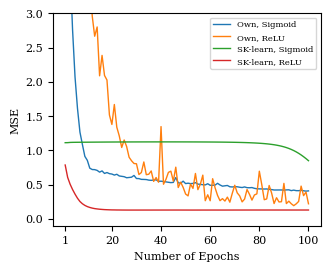

In [74]:
set_plot_params()
print(sig_mse[0])
print(relu_mse[0])
print(sk_sig_mse[0])
print(sk_relu_mse[0])

epochs = range(1,num_epochs+1)
plt.plot(epochs, sig_mse, label="Own, Sigmoid")
plt.plot(epochs, relu_mse, label="Own, ReLU")
plt.plot(epochs, sk_sig_mse, label="SK-learn, Sigmoid")
plt.plot(epochs, sk_relu_mse, label="SK-learn, ReLU")
#plt.plot(epochs, sk_sig_train_mse, label="SK-learn train, Sigmoid")
#plt.plot(epochs, sk_relu_train_mse, label = "SK-learn train, ReLU")

plt.ylim((-0.1,3))

plt.xticks([1, 20 ,40, 60, 80, 100])

plt.xlabel("Number of Epochs")
plt.ylabel("MSE")

plt.legend(loc="upper right")
plt.savefig("../fig/mse_comparison_sklearn.pdf")

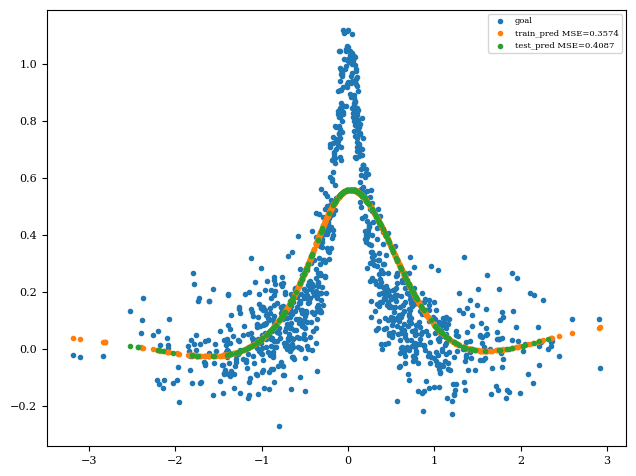

In [67]:
x_test_plot = scalerx.inverse_transform(X_test)[:,0]
y_test_plot = scalery.inverse_transform(test_pred)

x_train_plot = scalerx.inverse_transform(X_train)[:,0]
y_train_plot = scalery.inverse_transform(train_pred)
plt.scatter(xs, ys, marker = ".", label = "goal")
plt.scatter(x_train_plot, y_train_plot, marker=".", label = f"train_pred MSE={mse_train:.4g}")
plt.scatter(x_test_plot, y_test_plot, marker = ".", label = f"test_pred MSE={mse_test:.4g}")
#plt.scatter(X_train_plot, y_train, label = "train")

plt.legend()
plt.show()

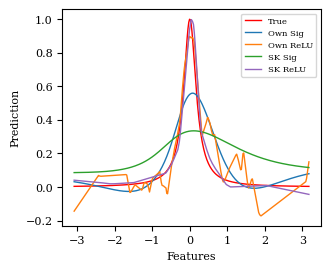

In [68]:
set_plot_params()
x_plot = np.linspace(-3, 3, 300)[:,np.newaxis]
x_plot = scalerx.transform(x_plot)

y_plot = runge_func(x_plot)

sk_relu_plot = sk_reg_relu.predict(x_plot)[:,np.newaxis]
sk_relu_plot = scalery.inverse_transform(sk_relu_plot)

sk_sig_plot = sk_reg_sig.predict(x_plot)[:,np.newaxis]
sk_sig_plot = scalery.inverse_transform(sk_sig_plot)

own_relu_plot = ffnn_relu.predict(x_plot)
own_relu_plot = scalery.inverse_transform(own_relu_plot)

own_sig_plot = ffnn.predict(x_plot)
own_sig_plot = scalery.inverse_transform(own_sig_plot)

plt.plot(x_plot, y_plot, color = "red",label="True")
plt.plot(x_plot, own_sig_plot, label="Own Sig")
plt.plot(x_plot, own_relu_plot, label ="Own ReLU")
plt.plot(x_plot, sk_sig_plot, label = "SK Sig")
plt.plot(x_plot, sk_relu_plot, color = "tab:purple",label = "SK ReLU")




#plt.scatter(X_train_plot, y_train, label = "train")

x_test_plot = scalerx.inverse_transform
plt.xlabel("Features")
plt.ylabel("Prediction")
plt.legend()
plt.savefig("../fig/rungefunc_fits_sklearn_comp.pdf")

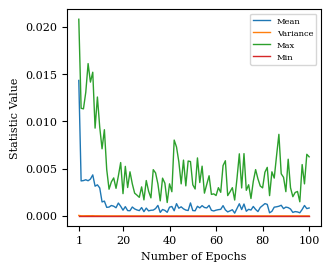

In [75]:
set_plot_params()

epochs = range(1,num_epochs+1)
plt.plot(epochs, relu_grad_avg, label="Mean")
plt.plot(epochs, relu_grad_var, label="Variance")
plt.plot(epochs, relu_grad_max, label="Max")
plt.plot(epochs, relu_grad_min, label="Min")
#plt.plot(epochs, sk_sig_train_mse, label="SK-learn train, Sigmoid")
#plt.plot(epochs, sk_relu_train_mse, label = "SK-learn train, ReLU")


plt.xticks([1, 20 ,40, 60, 80, 100])

plt.xlabel("Number of Epochs")
plt.ylabel("Statistic Value")

plt.legend(loc="upper right")
plt.savefig("../fig/stats_grad_relu.pdf")

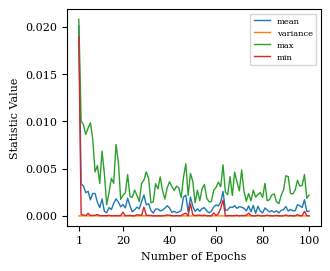

In [77]:
set_plot_params()

epochs = range(1,num_epochs+1)

plt.plot(epochs, sig_grad_avg, label="mean")
plt.plot(epochs, sig_grad_var, label="variance")
plt.plot(epochs, sig_grad_max, label="max")
plt.plot(epochs, sig_grad_min, label="min")

plt.xticks([1, 20 ,40, 60, 80, 100])

plt.xlabel("Number of Epochs")
plt.ylabel("Statistic Value")

plt.legend(loc="upper right")
plt.savefig("../fig/stats_grad_sig.pdf")